# 🎾 Coeficiente de Restitución — Análisis de Video

### Integrantes

Isaac David Sánchez Sánchez <br> Santiago Andrés Orejuela Cueter <br> Luis Mario Diaz Martínez <br> Maria Valentina Serna Gonzalez

---

## Fundamento físico

Cuando una pelota cae desde una altura $h_0$ y rebota, la altura del $n$-ésimo rebote es:

$$h_n = h_0 \cdot e^{2n}$$

El **coeficiente de restitución** $e$ ($0 \le e \le 1$) cuantifica la fracción de velocidad
conservada en cada rebote:

$$e = \frac{v_{\text{post-rebote}}}{v_{\text{pre-rebote}}} = \sqrt{\frac{h_{n+1}}{h_n}}$$

Para $e=1$ el choque es perfectamente elástico; para $e=0$ es perfectamente inelástico.

Tomando logaritmo:

$$\ln h_n = \ln h_0 + 2n \ln e$$

lo que permite estimar $e$ mediante **regresión lineal** sobre los pares $(n,\, \ln h_n)$.

---

## Pipeline de análisis

```
Video → Detección frame a frame → Trayectoria h(t) → Máximos → e
```

In [1]:
import sys
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.optimize import curve_fit
from IPython.display import display, HTML
import importlib

sys.path.insert(0, str(Path(".").resolve()))
import pelota_analyzer as pa
pa = importlib.reload(pa)
from pelota_analyzer import (
    build_figure,
    clean_trajectory,
    compute_restitution,
    detect_ball_positions,
    detect_bounces_and_peaks,
    pixel_to_height,
)

# ── Estilo matplotlib oscuro ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d0d1a",
    "axes.facecolor"  : "#131326",
    "axes.edgecolor"  : "#2a2a4a",
    "axes.labelcolor" : "#dde1f0",
    "xtick.color"     : "#dde1f0",
    "ytick.color"     : "#dde1f0",
    "text.color"      : "#dde1f0",
    "grid.color"      : "#2a2a4a",
    "grid.linewidth"  : 0.6,
    "font.family"     : "DejaVu Sans",
})

# ── Paleta de colores ────────────────────────────────────────────────────────
C = pa.C
_style = pa._style

print("✅  Módulos, paleta y _style cargados")

✅  Módulos, paleta y _style cargados


## ⚙️ Paso 0 — Configuración del análisis

Ajusta los parámetros según tu video antes de ejecutar el resto del notebook.

In [2]:
# ┌─────────────────────────────────────────────┐
# │  AJUSTA ESTOS PARÁMETROS SEGÚN TU VIDEO      │
# └─────────────────────────────────────────────┘

VIDEO_PATH = Path("pelota_plastico.mp4")   # ← Nombre de tu video
METHOD     = "bg"       # "bg" | "color" | "hough"
MIN_AREA   = 150        # área mínima del blob en px² (en imagen reducida)
RESIZE     = 0.25       # factor de reducción para procesar más rápido
MAX_FRAMES = None       # None = todos los frames; ej. 600 para probar rápido
SCALE_MPP    = None       # metros/pixel (None = resultados en px normalizado)
MAX_BOUNCES  = None       # None = automático; fija un límite si hay detecciones espurias

# Verificar que el video existe
if not VIDEO_PATH.exists():
    raise FileNotFoundError(f"Video no encontrado: {VIDEO_PATH}")

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps_raw  = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"📹  Video   : {VIDEO_PATH.name}")
print(f"    Tamaño  : {W}×{H} px")
print(f"    FPS     : {fps_raw:.2f}")
print(f"    Frames  : {n_frames}  ({n_frames/fps_raw:.1f} s)")
print(f"\n🔧  Método de detección : {METHOD}")
print(f"    Factor resize       : {RESIZE}  →  {int(W*RESIZE)}×{int(H*RESIZE)} px")

📹  Video   : pelota_plastico.mp4
    Tamaño  : 3840×2160 px
    FPS     : 29.97
    Frames  : 91  (3.0 s)

🔧  Método de detección : bg
    Factor resize       : 0.25  →  960×540 px


## 🎬 Paso 1 — Vista previa del video

Extraemos fotogramas representativos para verificar que el video cargó correctamente
y visualizar las condiciones de grabación.

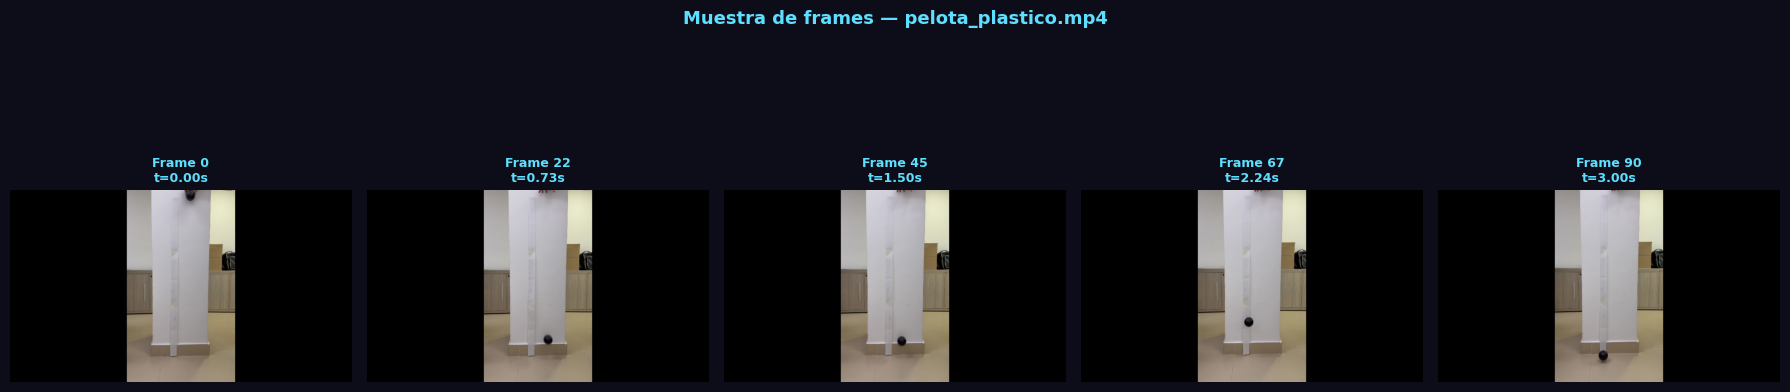

In [3]:
def show_sample_frames(video_path, n_samples=5, resize=0.25):
    """Muestra n fotogramas distribuidos uniformemente a lo largo del video."""
    cap   = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_v = cap.get(cv2.CAP_PROP_FPS)
    idxs  = np.linspace(0, total - 1, n_samples, dtype=int)

    fig, axes = plt.subplots(1, n_samples, figsize=(18, 5), facecolor=C["bg"])
    for ax, fi in zip(axes, idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            ax.axis("off")
            continue
        frame_rgb = cv2.cvtColor(
            cv2.resize(frame, (int(frame.shape[1]*resize), int(frame.shape[0]*resize))),
            cv2.COLOR_BGR2RGB
        )
        ax.imshow(frame_rgb)
        ax.set_title(f"Frame {fi}\nt={fi/fps_v:.2f}s",
                     color=C["accent"], fontsize=9, fontweight="bold")
        ax.axis("off")
    cap.release()
    fig.suptitle(f"Muestra de frames — {video_path.name}",
                 color=C["accent"], fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

show_sample_frames(VIDEO_PATH)

## 📡 Señal continua → representación discreta

El movimiento físico de la pelota es una señal **continua** en el tiempo.
Al capturar un video, esta señal se **discretiza** a una tasa de muestreo de $f_s$ fps.

### Límite de Nyquist

El **teorema de Nyquist** exige que $f_s > 2 f_{\text{máx}}$ para evitar aliasing.
Los rebotes ocurren en ~0.1 s → frecuencia característica ~10 Hz.
A 120 fps estamos bien por encima (factor ×6).

### Error por discretización temporal

La pelota puede estar en su punto más alto **entre dos frames consecutivos**:

$$\delta h_{\text{máx}} \approx \frac{1}{2} g \left(\frac{1}{f_s}\right)^2$$

Usamos **interpolación parabólica** alrededor del frame máximo para reducir este error.

## 📡 Señal continua → representación discreta

El movimiento físico de la pelota es una señal **continua** en el tiempo.
Al capturar un video, esta señal se **discretiza** a una tasa de muestreo de $f_s$ fps.

### Límite de Nyquist

El **teorema de Nyquist** exige que $f_s > 2 f_{\text{máx}}$ para evitar aliasing.
Los rebotes ocurren en ~0.1 s → frecuencia característica ~10 Hz.
A 120 fps estamos bien por encima (factor ×6).

### Error por discretización temporal

La pelota puede estar en su punto más alto **entre dos frames consecutivos**:

$$\delta h_{\text{máx}} \approx \frac{1}{2} g \left(\frac{1}{f_s}\right)^2$$

Usamos **interpolación parabólica** alrededor del frame máximo para reducir este error.

In [4]:
dt = 1.0 / fps_raw
g  = 9.8

print(f"Resolución temporal        : Δt = {dt*1000:.3f} ms")
print(f"Frecuencia de muestreo     : fs = {fps_raw:.1f} Hz")
print()

err_h_max_m = 0.5 * g * dt**2
print(f"Error máx. en h (temporal) : δh ≈ {err_h_max_m*1000:.3f} mm")
print()
print(f"Resolución espacial        : {W}×{H} px")
if SCALE_MPP:
    px_mm = SCALE_MPP * 1000
    print(f"Tamaño por pixel           : {px_mm:.3f} mm/px")
else:
    print("Calibración métrica        : no definida (resultados en px. norm.)")

Resolución temporal        : Δt = 33.367 ms
Frecuencia de muestreo     : fs = 30.0 Hz

Error máx. en h (temporal) : δh ≈ 5.455 mm

Resolución espacial        : 3840×2160 px
Calibración métrica        : no definida (resultados en px. norm.)


## 🔍 Paso 2 — Detección de la pelota en cada frame

Usamos **sustracción de fondo (MOG2)** combinada con análisis de blobs:

1. Sustracción de fondo → máscara de movimiento
2. Operaciones morfológicas (apertura + cierre) → eliminar ruido
3. Contornos → blob más grande → centroide $(x_i, y_i)$

El resultado es la posición de la pelota para cada frame $i$.

> **Alternativas disponibles:** `method="color"` (máscara HSV) · `method="hough"` (círculos de Hough).
> Prueba distintos métodos si la cobertura es baja.

In [5]:
positions_raw, times, fps, frame_size = detect_ball_positions(
    VIDEO_PATH,
    max_frames=MAX_FRAMES,
    min_area=MIN_AREA,
    method=METHOD,
    preview=False,
    resize_factor=RESIZE
)

detected = sum(1 for p in positions_raw if p is not None)
total    = len(positions_raw)
print(f"\nDetecciones válidas: {detected}/{total} ({detected/total*100:.1f}%)")


Detecciones válidas: 91/91 (100.0%)


### 📈 Cobertura de detección

Visualizamos qué frames tuvieron detección válida y cuáles no.
Una cobertura baja puede indicar problemas con el método elegido o la iluminación.

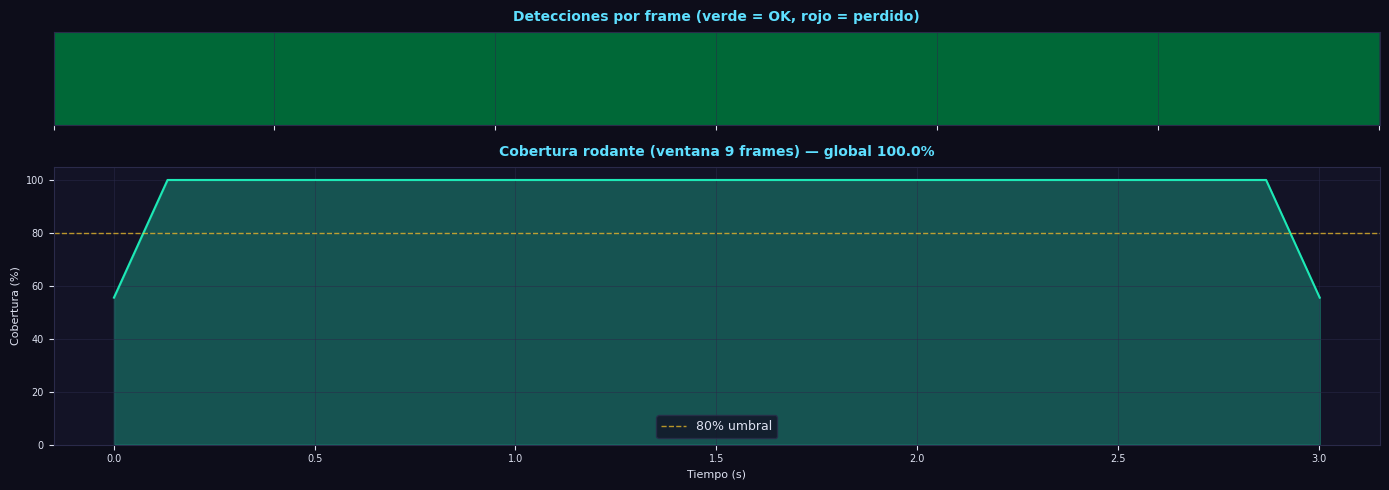


Cobertura global   : 100.0%
Frames sin detectar: 0 / 91


In [6]:
# ── Cobertura de detección ───────────────────────────────────────────────────
detected_mask = np.array([p is not None for p in positions_raw], dtype=int)
cov_global    = detected_mask.mean() * 100

# Ventana deslizante de 30 frames para ver cobertura local
window = min(30, len(detected_mask) // 10)
cov_rolling = np.convolve(detected_mask, np.ones(window)/window, mode='same') * 100

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 5),
                                      gridspec_kw={'height_ratios': [1, 3]},
                                      facecolor=C["bg"])

# Mapa binario (fila superior)
ax_top.imshow(detected_mask[np.newaxis, :], aspect='auto', cmap='RdYlGn',
              vmin=0, vmax=1, extent=[times[0], times[-1], 0, 1])
ax_top.set_yticks([])
ax_top.set_xlabel("")
_style(ax_top, "Detecciones por frame (verde = OK, rojo = perdido)", "", "")
ax_top.tick_params(labelbottom=False)

# Cobertura rodante
_style(ax_bot, f"Cobertura rodante (ventana {window} frames) — global {cov_global:.1f}%",
          "Tiempo (s)", "Cobertura (%)")
ax_bot.fill_between(times, cov_rolling, alpha=0.3, color=C["teal"])
ax_bot.plot(times, cov_rolling, color=C["teal"], lw=1.5)
ax_bot.axhline(80, color=C["gold"], lw=1, ls="--", alpha=0.7, label="80% umbral")
ax_bot.set_ylim(0, 105)
ax_bot.legend(fontsize=9, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])

plt.tight_layout()
plt.show()

print(f"\nCobertura global   : {cov_global:.1f}%")
print(f"Frames sin detectar: {(~detected_mask.astype(bool)).sum()} / {len(detected_mask)}")
if cov_global < 70:
    print("⚠️  Cobertura baja — considera cambiar METHOD o ajustar MIN_AREA / RESIZE.")


## 🔧 Paso 3 — Limpieza y suavizado de la señal

Los frames sin detección se rellenan por **interpolación lineal** y se aplica
un filtro **Savitzky-Golay** que suaviza el ruido de detección preservando los picos.

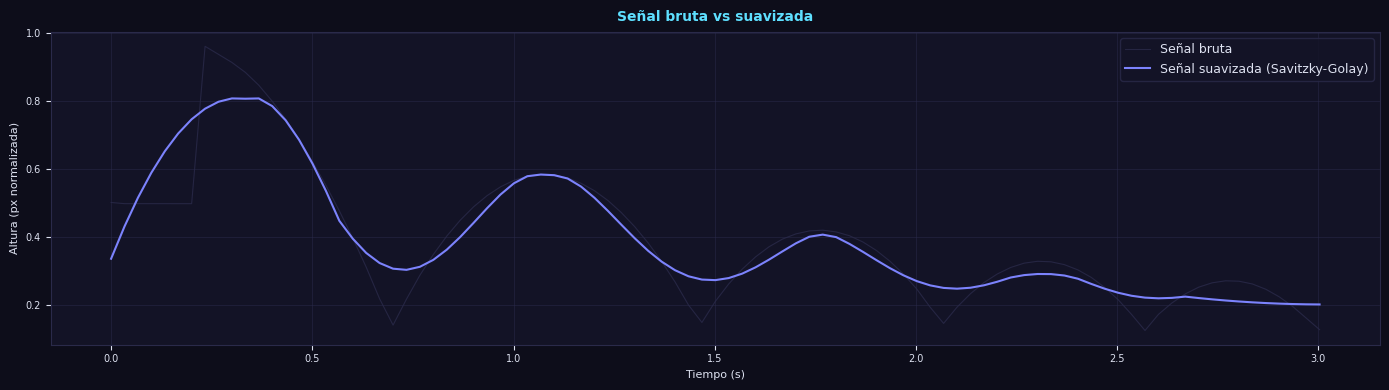

In [7]:
# Limpiar trayectoria
positions = clean_trajectory(positions_raw, times)

# Calcular alturas (invertir eje y: en imagen y crece hacia abajo)
height = pixel_to_height(positions[:, 1], frame_size[1], scale_mpp=SCALE_MPP)
ylabel = "Altura (m)" if SCALE_MPP else "Altura (px normalizada)"

# Señal bruta para comparar
h_raw = pixel_to_height(
    np.array([p[1] if p is not None else np.nan for p in positions_raw], dtype=float),
    frame_size[1], scale_mpp=SCALE_MPP
)

fig, ax = plt.subplots(figsize=(14, 4), facecolor=C["bg"])
_style(ax, "Señal bruta vs suavizada", "Tiempo (s)", ylabel)
ax.plot(times, h_raw,  color=C["border"],  lw=0.8, alpha=0.8, label="Señal bruta")
ax.plot(times, height, color=C["purple"], lw=1.5, label="Señal suavizada (Savitzky-Golay)")
ax.legend(fontsize=9, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])
plt.tight_layout()
plt.show()

## 🏀 Paso 4 — Detección de rebotes y alturas máximas

Identificamos los instantes de rebote (mínimos de $h$) y las alturas máximas entre
rebotes consecutivos con `scipy.signal.find_peaks`.

Para reducir el error de discretización temporal se aplica **interpolación parabólica**
alrededor del frame máximo de cada segmento: hallamos el vértice de la parábola
que pasa por los 3 puntos vecinos:

$$h(t) \approx A t^2 + B t + C \quad \Rightarrow \quad t^* = -\frac{B}{2A}, \quad h^* = h(t^*)$$

In [8]:
bounce_idx, peak_idx, peak_times, peak_heights = detect_bounces_and_peaks(
    height, times, fps, max_bounces=MAX_BOUNCES
)

unit = "m" if SCALE_MPP else "u.n."
print(f"Rebotes detectados : {len(bounce_idx)}")
print(f"Máximos detectados : {len(peak_heights)}")
print()
for i, (t, h_val) in enumerate(zip(peak_times, peak_heights)):
    print(f"  Rebote {i}: h = {h_val:.5f} {unit}  @ t = {t:.4f} s")

Rebotes detectados : 5
Máximos detectados : 3

  Rebote 0: h = 0.80850 u.n.  @ t = 0.3003 s
  Rebote 1: h = 0.58449 u.n.  @ t = 1.0677 s
  Rebote 2: h = 0.40775 u.n.  @ t = 1.7684 s


### Señal de altura con rebotes y máximos marcados

/var/folders/wx/r83dd8w53r76sb2fnt_wmx980000gn/T/ipykernel_68068/2455685950.py:28: UserWarning: Glyph 128160 (\N{DIAMOND SHAPE WITH A DOT INSIDE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/sorejuela/Desktop/Coeficiente de restitucion/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128160 (\N{DIAMOND SHAPE WITH A DOT INSIDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


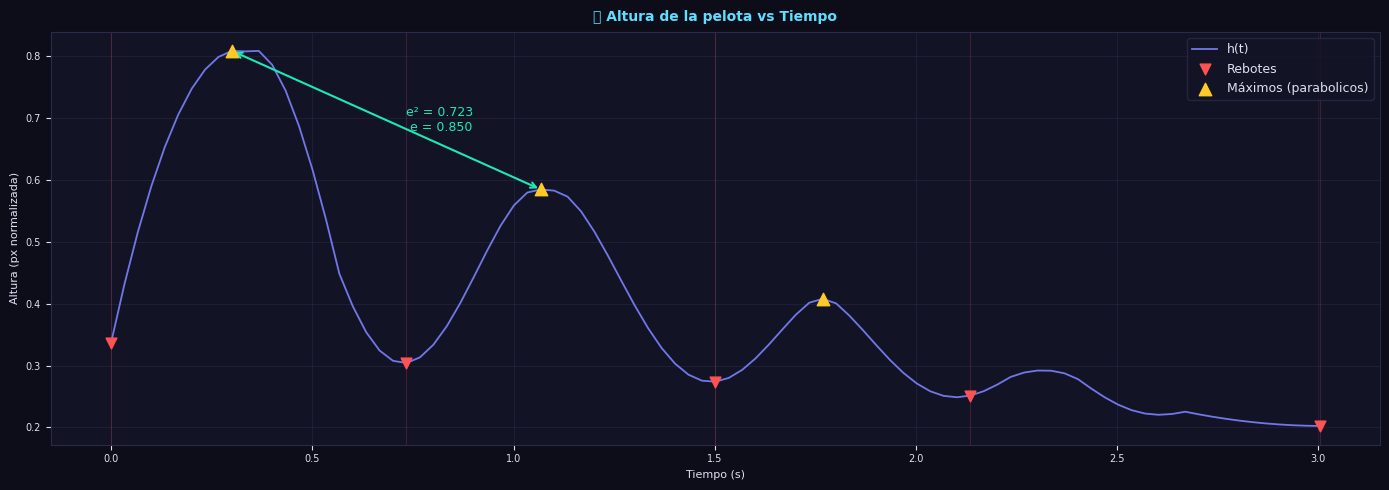

In [9]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor=C["bg"])
pa._style(ax, "💠 Altura de la pelota vs Tiempo", "Tiempo (s)", ylabel)

ax.plot(times, height, color=C["purple"], lw=1.3, alpha=0.9, label="h(t)")

if len(bounce_idx):
    ax.scatter(times[bounce_idx], height[bounce_idx],
               color=C["red"], s=60, zorder=5, label="Rebotes", marker="v")
if len(peak_times):
    ax.scatter(peak_times, peak_heights,
               color=C["gold"], s=80, zorder=6, label="Máximos (parabolicos)", marker="^")

# Anotar e² entre los dos primeros rebotes
if len(peak_heights) >= 2:
    h0, h1 = peak_heights[0], peak_heights[1]
    t0, t1 = peak_times[0],   peak_times[1]
    ax.annotate("", xy=(t1, h1), xytext=(t0, h0),
                arrowprops=dict(arrowstyle="<->", color=C["teal"], lw=1.5))
    ax.text((t0+t1)/2 + 0.05, (h0+h1)/2,
            f"e\u00b2 = {h1/h0:.3f}\n e = {np.sqrt(h1/h0):.3f}",
            color=C["teal"], fontsize=9, va="center")

# Líneas verticales en rebotes
for bi in bounce_idx:
    ax.axvline(times[bi], color=C["red"], alpha=0.2, lw=0.8)

ax.legend(fontsize=9, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])
plt.tight_layout()
plt.show()

## 📐 Paso 5 — Cálculo del coeficiente de restitución

### Método 1: Razón directa entre alturas sucesivas

$$e_i = \sqrt{\frac{h_{i+1}}{h_i}}$$

Ventaja: intuitivo. Desventaja: amplifica el error de medición de alturas individuales.

### Método 2: Regresión log-lineal

Tomando logaritmo en $h_n = h_0 \cdot e^{2n}$:

$$\ln h_n = \underbrace{\ln h_0}_{\text{intercepto}} + \underbrace{2 \ln e}_{\text{pendiente}} \cdot n$$

Un ajuste lineal de $\ln h_n$ vs $n$ da la pendiente $= 2\ln e$, y por tanto:

$$e = \exp\!\left(\frac{\text{pendiente}}{2}\right)$$

Esta forma es más robusta porque usa **todos** los rebotes simultáneamente.

In [10]:
e_successive, e_mean, e_std, e_regression, e_reg_err = \
    compute_restitution(peak_heights)

unit = "m" if SCALE_MPP else "u.n."
print("=" * 55)
print("  COEFICIENTE DE RESTITUCIÓN")
print("=" * 55)
print(f"  Alturas maximas : {[f'{h:.4f}' for h in peak_heights]}")
print()
print("  Método 1 — Razón directa:")
for i, (ei, h0_v, h1_v) in enumerate(zip(e_successive, peak_heights[:-1], peak_heights[1:])):
    print(f"    e({i}→{i+1}) = sqrt({h1_v:.4f}/{h0_v:.4f}) = {ei:.4f}")
print(f"    → e_medio = {e_mean:.4f} ± {e_std:.4f}")
print()
print(f"  Método 2 — Regresión log-lineal:")
print(f"    → e = {e_regression:.4f} ± {e_reg_err:.4f}")
print("=" * 55)

  COEFICIENTE DE RESTITUCIÓN
  Alturas maximas : ['0.8085', '0.5845', '0.4078']

  Método 1 — Razón directa:
    e(0→1) = sqrt(0.5845/0.8085) = 0.8503
    e(1→2) = sqrt(0.4078/0.5845) = 0.8352
    → e_medio = 0.8427 ± 0.0106

  Método 2 — Regresión log-lineal:
    → e = 0.8427 ± 0.0043


### Visualización de la regresión log-lineal

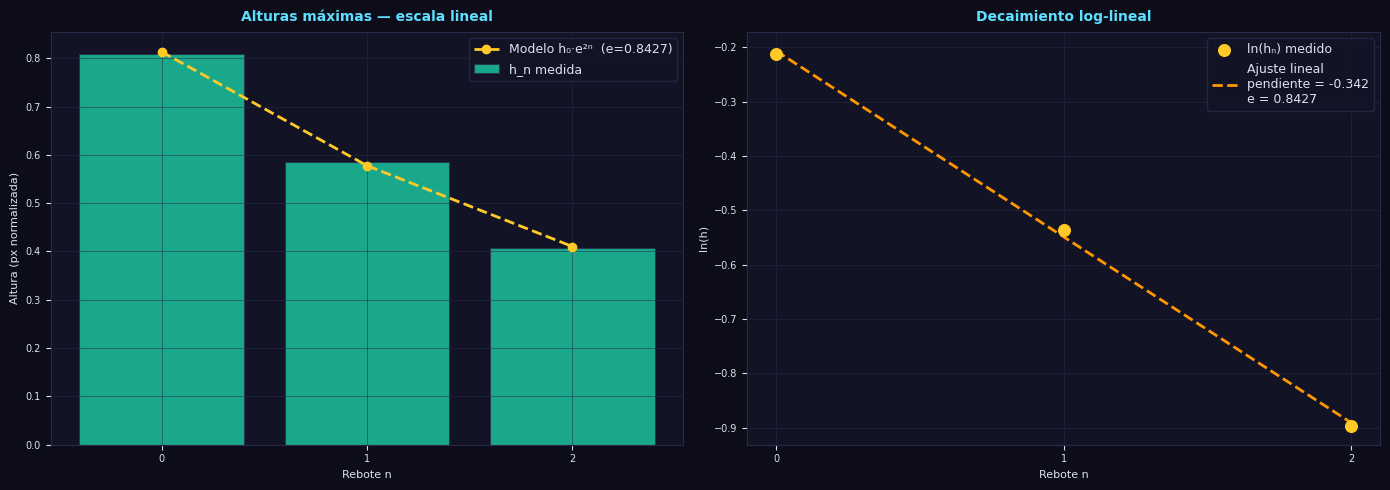

e calculado por reg. log-lineal: 0.8427


In [11]:
n_arr = np.arange(len(peak_heights))
log_h = np.log(peak_heights)

slope_v, intercept_v = np.polyfit(n_arr, log_h, 1)
n_fit   = np.linspace(0, n_arr[-1], 100)
log_fit = intercept_v + slope_v * n_fit
e_fit   = np.exp(slope_v / 2)
h_model = np.exp(intercept_v) * np.exp(slope_v * n_arr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=C["bg"])

# Panel izquierdo — escala lineal
_style(axes[0], "Alturas máximas — escala lineal", "Rebote n", ylabel)
axes[0].bar(n_arr, peak_heights, color=C["teal"], alpha=0.7,
            edgecolor=C["border"], linewidth=0.8, label="h_n medida")
axes[0].plot(n_arr, h_model, "o--", color=C["gold"], lw=2,
             label=f"Modelo h₀·e²ⁿ  (e={e_fit:.4f})")
axes[0].legend(fontsize=9, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])
axes[0].set_xticks(n_arr)

# Panel derecho — ln h vs n
_style(axes[1], "Decaimiento log-lineal", "Rebote n", "ln(h)")
axes[1].scatter(n_arr, log_h, color=C["gold"], s=70, zorder=5, label="ln(hₙ) medido")
axes[1].plot(n_fit, log_fit, "--", color=C["orange"], lw=2,
             label=f"Ajuste lineal\npendiente = {slope_v:.3f}\ne = {e_fit:.4f}")
axes[1].legend(fontsize=9, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])
axes[1].set_xticks(n_arr)

plt.tight_layout()
plt.show()
print(f"e calculado por reg. log-lineal: {e_fit:.4f}")

### 📉 Bondad del ajuste — R² y residuos

Cuantificamos qué tan bien el modelo exponencial describe los datos medidos.
El **coeficiente de determinación** R² indica la fracción de varianza explicada por la regresión.

R²   = 0.999097   (1.0 = ajuste perfecto)
RMSE = 0.014556  (en unidades de ln h)
Residuos (ln h): [-0.00594  0.01188 -0.00594]


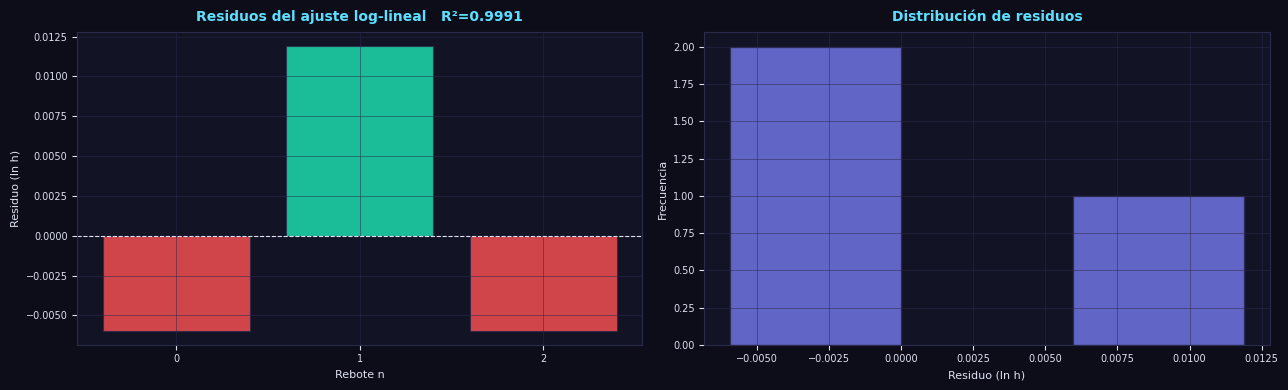

In [12]:
# ── R² y análisis de residuos ────────────────────────────────────────────────
from scipy.stats import pearsonr

n_arr_r  = np.arange(len(peak_heights))
log_h_r  = np.log(peak_heights)
slope_r, intercept_r = np.polyfit(n_arr_r, log_h_r, 1)
log_pred = intercept_r + slope_r * n_arr_r
residuos = log_h_r - log_pred

ss_res = np.sum(residuos**2)
ss_tot = np.sum((log_h_r - log_h_r.mean())**2)
r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
rmse   = np.sqrt(ss_res / max(len(log_h_r) - 2, 1))

print(f"R²   = {r2:.6f}   (1.0 = ajuste perfecto)")
print(f"RMSE = {rmse:.6f}  (en unidades de ln h)")
print(f"Residuos (ln h): {np.round(residuos, 5)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=C["bg"])

# Residuos vs rebote
_style(axes[0], f"Residuos del ajuste log-lineal   R²={r2:.4f}", "Rebote n", "Residuo (ln h)")
axes[0].axhline(0, color=C["text"], lw=0.8, ls="--")
axes[0].bar(n_arr_r, residuos, color=[C["teal"] if r >= 0 else C["red"] for r in residuos],
             alpha=0.8, edgecolor=C["border"], linewidth=0.8)
axes[0].set_xticks(n_arr_r)

# QQ-plot informal
_style(axes[1], "Distribución de residuos", "Residuo (ln h)", "Frecuencia")
axes[1].hist(residuos, bins=max(3, len(residuos)//2), color=C["purple"], alpha=0.75,
              edgecolor=C["border"])

plt.tight_layout()
plt.show()


## 📊 Reporte visual completo

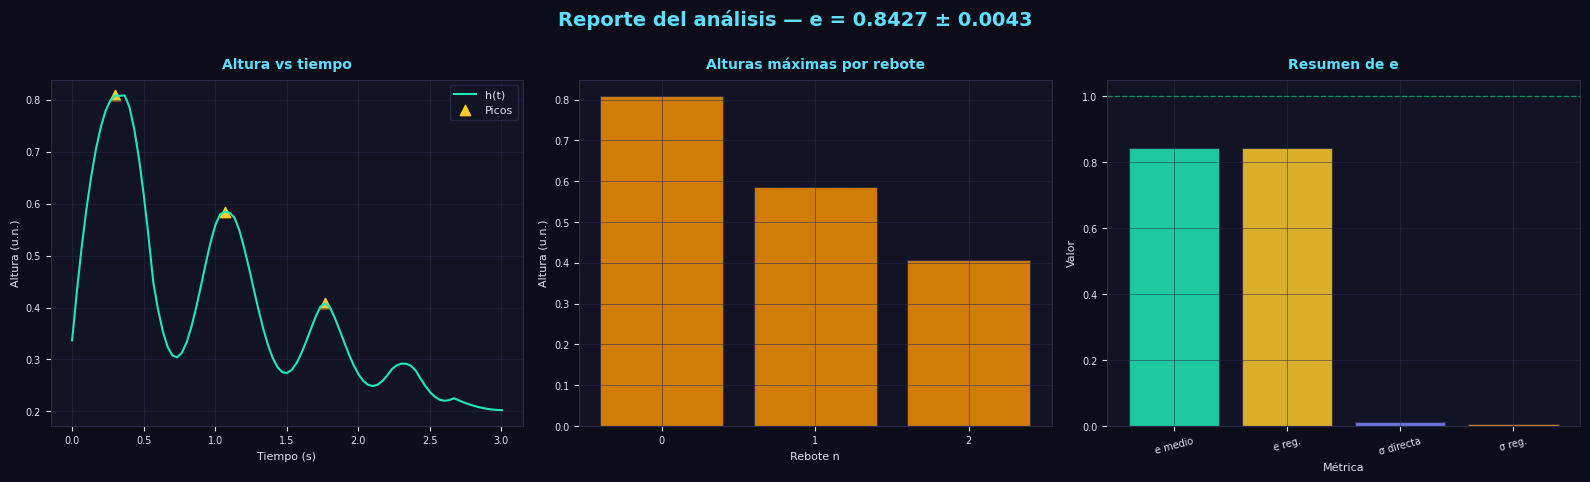

In [13]:
out_dir = Path("resultados")
out_dir.mkdir(exist_ok=True)

fig = build_figure(
    positions, height, times, fps,
    bounce_idx, peak_idx, peak_times, peak_heights,
    e_successive, e_mean, e_std, e_regression, e_reg_err,
    scale_mpp=SCALE_MPP,
    out_path=out_dir / f"{VIDEO_PATH.stem}_reporte.png"
)
plt.show()

## ⚠️ Análisis de fuentes de error

Esta sección reflexiona cuantitativamente sobre el proceso de medición
y sus limitaciones inherentes.

In [14]:
print("Fuentes de error y estimación cuantitativa")
print("=" * 55)

dt_v = 1.0 / fps
g_v  = 9.8

# 1. Error temporal
err_t = 0.5 * g_v * dt_v**2
print(f"\n1. Discretización temporal (fps={fps:.0f}):")
print(f"   Δh_max = 0.5·g·(Δt)² = {err_t*1000:.3f} mm")
if SCALE_MPP and len(peak_heights):
    rel = err_t / (peak_heights[0] * SCALE_MPP) * 100
    print(f"   Error relativo en h₀  ≈ {rel:.2f}%")

# 2. Resolución espacial
print(f"\n2. Resolución espacial:")
print(f"   Frame original : {frame_size[0]}×{frame_size[1]} px")
print(f"   Frame procesado: {int(frame_size[0]*RESIZE)}×{int(frame_size[1]*RESIZE)} px")
if SCALE_MPP:
    px_mm = SCALE_MPP / RESIZE * 1000
    print(f"   1 px procesado ≈ {px_mm:.2f} mm en la escena")

# 3. Variabilidad estadística en e
print(f"\n3. Variabilidad estadística en e:")
print(f"   e_medio = {e_mean:.4f}")
print(f"   sigma(e)= {e_std:.4f}")
if e_mean > 0:
    print(f"   CV(e)   = {e_std/e_mean*100:.2f}%")

# 4. Perspectiva
print(f"\n4. Efectos de perspectiva:")
print(f"   - Si la pelota no rebota en el plano perpendicular a la cámara,")
print(f"     la altura en píxeles subestima la real.")
print(f"   - La lente introduce distorsión (mayor en bordes del frame).")

# 5. Filtro SG
win_v = min(21, len(height) // 6 * 2 + 1)
win_v = max(win_v, 5)
print(f"\n5. Filtro Savitzky-Golay:")
print(f"   Ventana : {win_v} frames = {win_v/fps*1000:.1f} ms")
print(f"   Orden   : 3 (polinomio cúbico)")
print(f"   El filtro preserva picos pero puede atenuarlos ligeramente")
print(f"   si la ventana es comparable al tiempo de vuelo entre rebotes.")

Fuentes de error y estimación cuantitativa

1. Discretización temporal (fps=30):
   Δh_max = 0.5·g·(Δt)² = 5.455 mm

2. Resolución espacial:
   Frame original : 3840×2160 px
   Frame procesado: 960×540 px

3. Variabilidad estadística en e:
   e_medio = 0.8427
   sigma(e)= 0.0106
   CV(e)   = 1.26%

4. Efectos de perspectiva:
   - Si la pelota no rebota en el plano perpendicular a la cámara,
     la altura en píxeles subestima la real.
   - La lente introduce distorsión (mayor en bordes del frame).

5. Filtro Savitzky-Golay:
   Ventana : 21 frames = 700.7 ms
   Orden   : 3 (polinomio cúbico)
   El filtro preserva picos pero puede atenuarlos ligeramente
   si la ventana es comparable al tiempo de vuelo entre rebotes.


## 🧲 Validación física — Caída libre entre rebotes

Entre cada par de rebotes la pelota sigue un movimiento parabólico bajo gravedad:

$$h(t) = h_{\text{máx}} - \tfrac{1}{2}g\,(t - t_{\text{máx}})^2$$

Ajustamos esta parábola en cada segmento y verificamos que la *g* recuperada
sea consistente con 9.8 m/s². Una desviación grande indica error de perspectiva
o de calibración métrica.

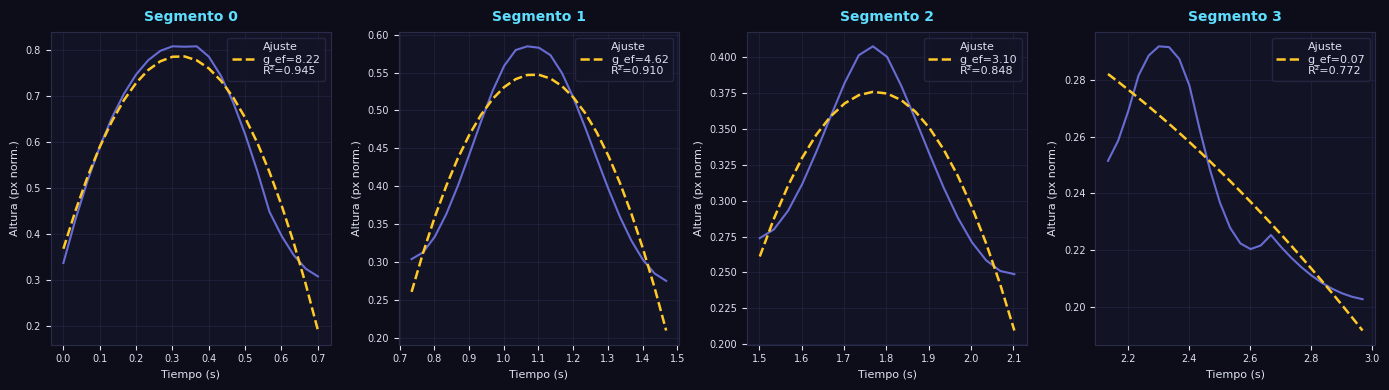


R² del ajuste parabólico por segmento: ['0.945', '0.910', '0.848', '0.772']
(Sin calibración métrica no se puede verificar g absoluto.)


In [15]:
# ── Validación de caída libre ─────────────────────────────────────────────────
from scipy.optimize import curve_fit

def parabola(t, h_max, t_max, g_eff):
    return h_max - 0.5 * g_eff * (t - t_max)**2

g_values   = []
r2_values  = []

ylabel_ff  = "Altura (m)" if SCALE_MPP else "Altura (px norm.)"
fig, axes  = plt.subplots(1, max(len(bounce_idx)-1, 1), figsize=(14, 4), facecolor=C["bg"])
axes = np.atleast_1d(axes).ravel()
segment_count = min(max(len(bounce_idx) - 1, 0), len(axes))

for seg_idx in range(segment_count):
    i0 = bounce_idx[seg_idx]
    i1 = bounce_idx[seg_idx + 1]
    t_seg = times[i0:i1]
    h_seg = height[i0:i1]

    ax = axes[seg_idx]
    _style(ax, f"Segmento {seg_idx}", "Tiempo (s)", ylabel_ff)

    ax.plot(t_seg, h_seg, color=C["purple"], lw=1.5, alpha=0.8)

    try:
        peak_ref = min(seg_idx, len(peak_heights) - 1)
        p0 = [peak_heights[peak_ref], peak_times[peak_ref], 9.8 if SCALE_MPP else 1e4]
        popt, _ = curve_fit(parabola, t_seg, h_seg, p0=p0, maxfev=4000)
        h_fit = parabola(t_seg, *popt)
        g_rec = abs(popt[2])
        ss_r  = np.sum((h_seg - h_fit)**2)
        ss_t  = np.sum((h_seg - h_seg.mean())**2)
        r2_ff = 1 - ss_r/ss_t if ss_t > 0 else 1.0
        g_values.append(g_rec)
        r2_values.append(r2_ff)
        ax.plot(t_seg, h_fit, "--", color=C["gold"], lw=1.8, label=f"Ajuste\ng_ef={g_rec:.2f}\nR²={r2_ff:.3f}")
        ax.legend(fontsize=8, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])
    except Exception:
        ax.text(0.5, 0.5, "Ajuste\nfallido", transform=ax.transAxes,
                color=C["red"], ha="center", va="center")

plt.tight_layout()
plt.show()

if g_values and SCALE_MPP:
    print(f"\ng recuperadas por segmento: {[f'{g:.2f}' for g in g_values]} m/s²")
    print(f"Media: {np.mean(g_values):.2f} ± {np.std(g_values):.2f} m/s²  (referencia: 9.80 m/s²)")
    desv = abs(np.mean(g_values) - 9.80) / 9.80 * 100
    print(f"Desviación relativa de g: {desv:.1f}%")
    if desv > 15:
        print("⚠️  Desviación > 15% — revisar calibración SCALE_MPP o perspectiva.")
elif g_values:
    print(f"\nR² del ajuste parabólico por segmento: {[f'{r:.3f}' for r in r2_values]}")
    print("(Sin calibración métrica no se puede verificar g absoluto.)")


## 🔬 Análisis de sensibilidad — Robustez de *e*

¿Cuánto cambia la estimación de *e* si excluimos el primer o último rebote?
Este análisis evalúa la estabilidad del resultado ante outliers en los picos detectados.

In [16]:
# ── Análisis de sensibilidad ─────────────────────────────────────────────────
N = len(peak_heights)

if N >= 4:
    sens_results = []
    labels_sens  = []

    # Subconjuntos: todos, sin primero, sin último, sin primero ni último,
    # primera mitad, segunda mitad
    subsets = {
        "Todos"          : slice(None),
        "Sin rebote 0"   : slice(1, None),
        "Sin último"     : slice(None, -1),
        "Sin 0 ni último": slice(1, -1),
    }
    if N >= 6:
        subsets["Primera mitad"]  = slice(None, N//2 + 1)
        subsets["Segunda mitad"]  = slice(N//2, None)

    for lbl, sl in subsets.items():
        ph_sub = peak_heights[sl]
        if len(ph_sub) < 2:
            continue
        n_sub    = np.arange(len(ph_sub))
        log_sub  = np.log(ph_sub)
        sl_sub, ic_sub = np.polyfit(n_sub, log_sub, 1)
        e_sub = np.exp(sl_sub / 2)
        sens_results.append(e_sub)
        labels_sens.append(lbl)

    fig, ax = plt.subplots(figsize=(10, 4), facecolor=C["bg"])
    _style(ax, "Sensibilidad de e según subconjunto de rebotes", "Subconjunto", "e estimado")
    colors_s = [C["teal"] if l == "Todos" else C["purple"] for l in labels_sens]
    bars = ax.bar(range(len(sens_results)), sens_results, color=colors_s,
                  alpha=0.85, edgecolor=C["border"], linewidth=0.8)
    for i, (b, v) in enumerate(zip(bars, sens_results)):
        ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
                ha='center', va='bottom', color=C["text"], fontsize=10, fontweight='bold')
    ax.axhline(e_regression, color=C["gold"], lw=1.5, ls="--",
               label=f"e global = {e_regression:.4f}")
    ax.set_xticks(range(len(labels_sens)))
    ax.set_xticklabels(labels_sens, rotation=25, ha='right', fontsize=9)
    ax.set_ylim(max(0, min(sens_results) - 0.05), min(1.05, max(sens_results) + 0.05))
    ax.legend(fontsize=9, facecolor=C["panel"], edgecolor=C["border"], labelcolor=C["text"])
    plt.tight_layout()
    plt.show()

    spread = max(sens_results) - min(sens_results)
    print(f"Rango de e entre subconjuntos: {min(sens_results):.4f} – {max(sens_results):.4f}")
    print(f"Dispersión total              : {spread:.4f}")
    if spread < 0.02:
        print("✅  Alta robustez: el resultado es consistente entre subconjuntos.")
    elif spread < 0.05:
        print("⚠️  Robustez moderada: hay cierta sensibilidad al subconjunto elegido.")
    else:
        print("❌  Baja robustez: revisar los picos detectados manualmente.")
else:
    print("Se necesitan al menos 4 rebotes para el análisis de sensibilidad.")
    print(f"Actualmente se detectaron: {N} rebotes.")


Se necesitan al menos 4 rebotes para el análisis de sensibilidad.
Actualmente se detectaron: 3 rebotes.


### 📏 Propagación formal de incertidumbre en *e*

La incertidumbre en cada altura $h_n$ se debe principalmente a la resolución espacial.
Propagando formalmente a través de la regresión log-lineal:

$$\sigma_e = e \cdot \frac{\sigma_{\ln h}}{\sqrt{2}} \cdot \frac{1}{\sqrt{\sum (n_i - \bar n)^2}}$$

In [17]:
# ── Propagación formal de incertidumbre ──────────────────────────────────────
if len(peak_heights) >= 2:
    n_unc    = np.arange(len(peak_heights))
    log_h_u  = np.log(peak_heights)
    slope_u, intercept_u = np.polyfit(n_unc, log_h_u, 1)

    # Incertidumbre desde los residuos del ajuste (estimación realista)
    log_pred_u = intercept_u + slope_u * n_unc
    sigma_lnh  = np.std(log_h_u - log_pred_u)          # residual std
    Sxx        = np.sum((n_unc - n_unc.mean())**2)

    # Incertidumbre en la pendiente (fórmula regresión lineal)
    sigma_slope = sigma_lnh / np.sqrt(Sxx) if Sxx > 0 else 0
    # Propagación: e = exp(slope/2) → σ_e = e * |σ_slope / 2|
    sigma_e_prop = e_regression * sigma_slope / 2

    # Contribución de discretización espacial (1 píx procesado)
    if SCALE_MPP:
        sigma_h_px  = SCALE_MPP / RESIZE            # m / px procesado
        sigma_lnh_px = sigma_h_px / np.mean(peak_heights)
        sigma_e_spatial = e_regression * sigma_lnh_px / 2
    else:
        sigma_h_px     = 1.0 / frame_size[1] / RESIZE   # en px normalizados
        sigma_lnh_px   = sigma_h_px / np.mean(peak_heights)
        sigma_e_spatial = e_regression * sigma_lnh_px / 2

    sigma_e_total = np.sqrt(sigma_e_prop**2 + sigma_e_spatial**2)

    print("=" * 55)
    print("  PROPAGACIÓN DE INCERTIDUMBRE EN e")
    print("=" * 55)
    print(f"  σ(ln h) residual           : {sigma_lnh:.5f}")
    print(f"  σ(pendiente)               : {sigma_slope:.5f}")
    print(f"  σ_e por ajuste             : {sigma_e_prop:.5f}")
    print(f"  σ_e por resolución espacial: {sigma_e_spatial:.5f}")
    print(f"  σ_e TOTAL (combinada)      : {sigma_e_total:.5f}")
    print()
    print(f"  Resultado final: e = {e_regression:.4f} ± {sigma_e_total:.4f}")
    print(f"  (intervalo 1σ: [{e_regression-sigma_e_total:.4f}, {e_regression+sigma_e_total:.4f}])")

    # Actualizar para usar en conclusiones
    E_FINAL       = e_regression
    E_FINAL_UNC   = sigma_e_total
    E_DIRECTO     = e_mean
    E_DIRECTO_UNC = e_std


  PROPAGACIÓN DE INCERTIDUMBRE EN e
  σ(ln h) residual           : 0.00840
  σ(pendiente)               : 0.00594
  σ_e por ajuste             : 0.00250
  σ_e por resolución espacial: 0.00130
  σ_e TOTAL (combinada)      : 0.00282

  Resultado final: e = 0.8427 ± 0.0028
  (intervalo 1σ: [0.8399, 0.8455])


In [18]:
out_dir = Path("resultados")
out_dir.mkdir(exist_ok=True)

# CSV trayectoria completa
csv_traj  = out_dir / f"{VIDEO_PATH.stem}_trayectoria.csv"
data_traj = np.column_stack([times, positions[:, 0], positions[:, 1], height])
np.savetxt(csv_traj, data_traj, delimiter=",",
           header="tiempo_s,x_px,y_px,altura", comments="")

# CSV de picos
csv_picos  = out_dir / f"{VIDEO_PATH.stem}_picos.csv"
e_col      = np.r_[np.nan, e_successive]
data_picos = np.column_stack([np.arange(len(peak_heights)), peak_times, peak_heights, e_col])
np.savetxt(csv_picos, data_picos, delimiter=",",
           header="rebote_n,tiempo_s,altura,e_i", comments="")

print(f"✅  Trayectoria → {csv_traj}")
print(f"✅  Picos       → {csv_picos}")

# Tabla de resumen
unit = "m" if SCALE_MPP else "u.n."
print(f"\n{'Rebote':>8} | {'Tiempo (s)':>10} | {'Altura':>12} | {'e_i':>8}")
print("-" * 48)
for i, (t, h_val) in enumerate(zip(peak_times, peak_heights)):
    e_str = f"{e_successive[i-1]:.4f}" if i > 0 else "—"
    print(f"{'n='+str(i):>8} | {t:>10.4f} | {h_val:>10.5f} {unit} | {e_str:>8}")
print()
print(f"  e (razón directa)  : {e_mean:.4f} ± {e_std:.4f}")
print(f"  e (regresión log.) : {e_regression:.4f} ± {e_reg_err:.4f}")

✅  Trayectoria → resultados/pelota_plastico_trayectoria.csv
✅  Picos       → resultados/pelota_plastico_picos.csv

  Rebote | Tiempo (s) |       Altura |      e_i
------------------------------------------------
     n=0 |     0.3003 |    0.80850 u.n. |        —
     n=1 |     1.0677 |    0.58449 u.n. |   0.8503
     n=2 |     1.7684 |    0.40775 u.n. |   0.8352

  e (razón directa)  : 0.8427 ± 0.0106
  e (regresión log.) : 0.8427 ± 0.0043
